Libraries imported successfully.
Dataset Shape: (3000, 12)


,Customer_ID,Age,Tenure_Months,Monthly_Charges,Support_Calls,Login_Frequency,Usage_Hours,Discount_Usage,Payment_Delays,Satisfaction_Score,Total_Spend,Churn
0,1,56,12,112.94,5,9,27.75,43.02,5,10,2396.46,1
1,2,69,47,95.27,3,22,63.68,1.86,2,6,8106.35,0
2,3,46,18,21.90,4,15,17.76,53.98,4,6,4112.18,1
3,4,32,21,66.85,4,20,59.34,98.93,1,6,6770.47,0
4,5,60,13,98.63,3,3,75.92,34.97,2,5,5028.70,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         3000 non-null   int64  
 1   Age                 3000 non-null   int64  
 2   Tenure_Months       3000 non-null   int64  
 3   Monthly_Charges     3000 non-null   float64
 4   Support_Calls       3000 non-null   int64  
 5   Login_Frequency     3000 non-null   int64  
 6   Usage_Hours         3000 non-null   float64
 7   Discount_Usage      3000 non-null   float64
 8   Payment_Delays      3000 non-null   int64  
 9   Satisfaction_Score  3000 non-null   int64  
 10  Total_Spend         3000 non-null   float64
 11  Churn               3000 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 281.4 KB

Missing Values:
Customer_ID           0
Age                   0
Tenure_Months         0
Monthly_Charges       0
Support_Calls       

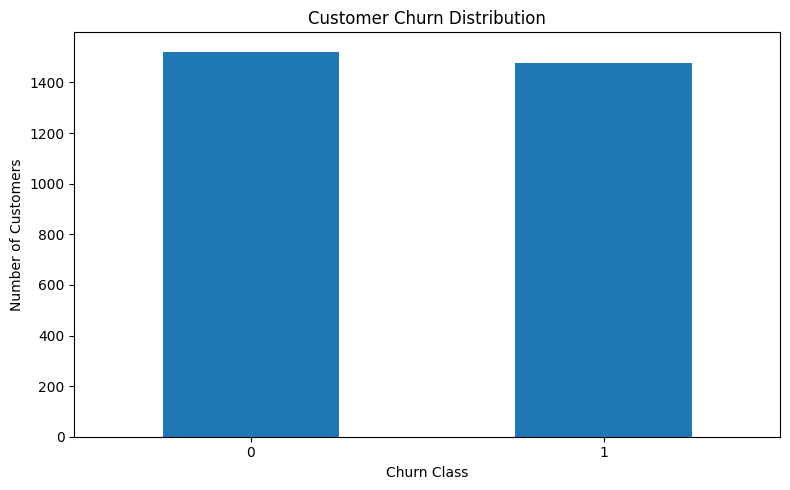


Training Samples: 2400
Testing Samples: 600

Baseline XGBoost model trained.

Baseline Model Metrics:


,Metric,Score
0,Accuracy,0.578333
1,Precision,0.568690
2,Recall,0.601351
3,F1 Score,0.584565
4,ROC-AUC,0.609653



Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.56      0.57       304
           1       0.57      0.60      0.58       296

    accuracy                           0.58       600
   macro avg       0.58      0.58      0.58       600
weighted avg       0.58      0.58      0.58       600


Confusion Matrix:
[[169 135]
 [118 178]]


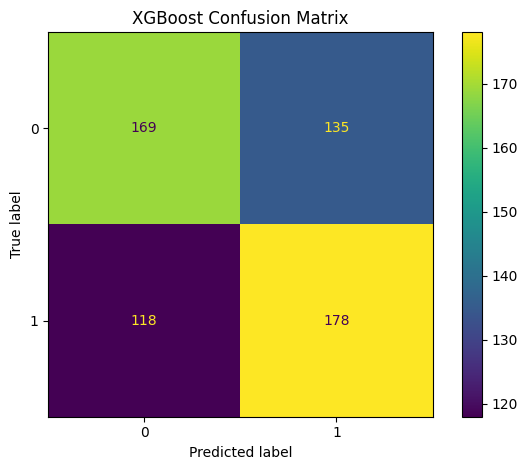

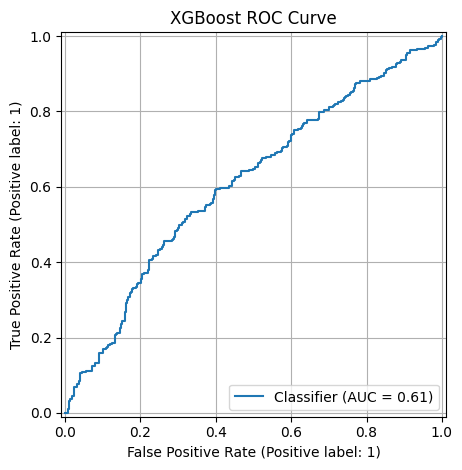


Feature Importance:


,Feature,Importance
8,Satisfaction_Score,0.124110
1,Tenure_Months,0.120415
2,Monthly_Charges,0.113618
9,Total_Spend,0.097732
5,Usage_Hours,0.094659
6,Discount_Usage,0.094237
4,Login_Frequency,0.093074
3,Support_Calls,0.089167
0,Age,0.087395
7,Payment_Delays,0.085592


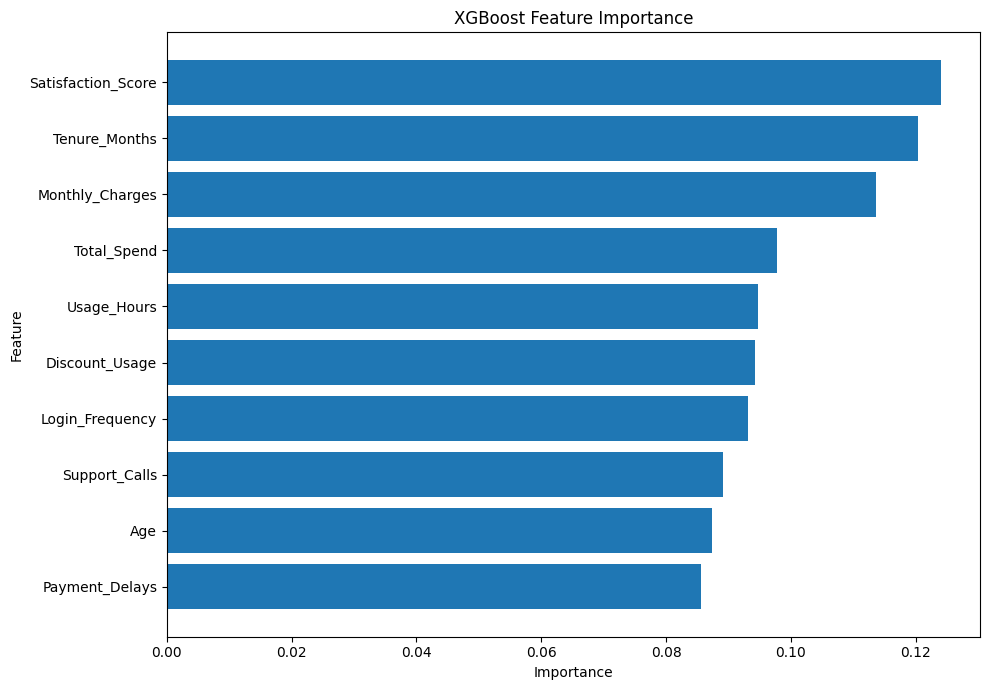

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters:
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}

Best Cross-Validation ROC-AUC:
0.6237090845440224

Tuned XGBoost model ready.

Tuned Model Metrics:


,Metric,Score
0,Accuracy,0.593333
1,Precision,0.583871
2,Recall,0.611486
3,F1 Score,0.597360
4,ROC-AUC,0.623944



Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59       304
           1       0.58      0.61      0.60       296

    accuracy                           0.59       600
   macro avg       0.59      0.59      0.59       600
weighted avg       0.59      0.59      0.59       600



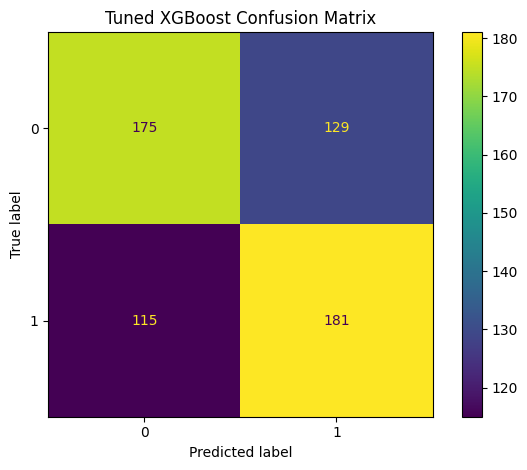

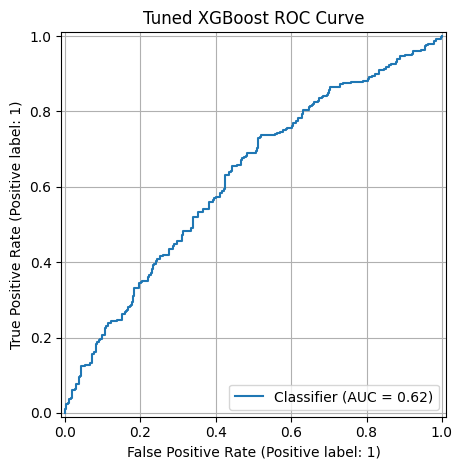


Tuned Feature Importance:


,Feature,Importance
8,Satisfaction_Score,0.150145
1,Tenure_Months,0.145222
2,Monthly_Charges,0.133522
4,Login_Frequency,0.087670
6,Discount_Usage,0.083576
9,Total_Spend,0.083181
0,Age,0.080894
5,Usage_Hours,0.080830
7,Payment_Delays,0.078668
3,Support_Calls,0.076291



Baseline vs Tuned:


,Metric,Baseline,Tuned
0,Accuracy,0.578333,0.593333
1,Precision,0.568690,0.583871
2,Recall,0.601351,0.611486
3,F1 Score,0.584565,0.597360
4,ROC-AUC,0.609653,0.623944



New Customer Prediction
Predicted Churn: 1
Churn Probability: 0.7085

DAY 29 - XGBOOST CUSTOMER CHURN PREDICTION COMPLETED

Baseline ROC-AUC: 0.6097
Tuned ROC-AUC: 0.6239
Tuned Accuracy: 0.5933
Tuned F1 Score: 0.5974

New Customer Churn Probability: 0.7085

Generated Files:
- baseline_feature_importance.csv
- baseline_metrics.csv
- best_parameters.csv
- churn_distribution.png
- confusion_matrix.png
- customer_churn_dataset.csv
- feature_importance.png
- feature_list.pkl
- model_comparison.csv
- new_customer_prediction.csv
- roc_curve.png
- tuned_confusion_matrix.png
- tuned_feature_importance.csv
- tuned_metrics.csv
- tuned_roc_curve.png
- xgboost_churn_model.pkl


In [1]:
# ============================================================
# DAY 29 - XGBOOST CUSTOMER CHURN PREDICTION
# Advanced Supervised Machine Learning
# ============================================================

# ============================================================
# 1. INSTALL XGBOOST
# ============================================================

!pip -q install xgboost


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

OUTPUT_DIR = "day29_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

np.random.seed(
    RANDOM_STATE
)

print("Libraries imported successfully.")


# ============================================================
# 3. CREATE CUSTOMER CHURN DATASET
# ============================================================

n_customers = 3000

customer_df = pd.DataFrame({

    "Age": np.random.randint(
        18,
        70,
        n_customers
    ),

    "Tenure_Months": np.random.randint(
        1,
        72,
        n_customers
    ),

    "Monthly_Charges": np.random.uniform(
        20,
        150,
        n_customers
    ).round(2),

    "Support_Calls": np.random.poisson(
        3,
        n_customers
    ),

    "Login_Frequency": np.random.randint(
        1,
        31,
        n_customers
    ),

    "Usage_Hours": np.random.uniform(
        1,
        80,
        n_customers
    ).round(2),

    "Discount_Usage": np.random.uniform(
        0,
        100,
        n_customers
    ).round(2),

    "Payment_Delays": np.random.poisson(
        2,
        n_customers
    ),

    "Satisfaction_Score": np.random.randint(
        1,
        11,
        n_customers
    ),

    "Total_Spend": np.random.uniform(
        100,
        10000,
        n_customers
    ).round(2)
})


# ============================================================
# 4. CREATE REALISTIC CHURN TARGET
# ============================================================

churn_score = (

    0.025
    * customer_df["Support_Calls"]

    + 0.035
    * customer_df["Payment_Delays"]

    - 0.015
    * customer_df["Tenure_Months"]

    - 0.10
    * customer_df["Satisfaction_Score"]

    - 0.015
    * customer_df["Login_Frequency"]

    + 0.008
    * customer_df["Monthly_Charges"]

)

probability = (
    1 /
    (
        1 +
        np.exp(
            -(
                churn_score
                - churn_score.mean()
            )
        )
    )
)

customer_df["Churn"] = (
    np.random.random(
        n_customers
    )
    < probability
).astype(int)


# ============================================================
# 5. CUSTOMER ID
# ============================================================

customer_df.insert(
    0,
    "Customer_ID",
    range(
        1,
        n_customers + 1
    )
)


# ============================================================
# 6. DISPLAY DATASET
# ============================================================

print(
    "Dataset Shape:",
    customer_df.shape
)

display(
    customer_df.head()
)


# ============================================================
# 7. DATA INFORMATION
# ============================================================

print(
    "\nDataset Information:"
)

customer_df.info()


# ============================================================
# 8. MISSING VALUE CHECK
# ============================================================

print(
    "\nMissing Values:"
)

print(
    customer_df.isnull().sum()
)


# ============================================================
# 9. CLASS DISTRIBUTION
# ============================================================

print(
    "\nChurn Distribution:"
)

print(
    customer_df["Churn"].value_counts()
)

print(
    "\nChurn Percentage:"
)

print(
    customer_df["Churn"]
    .value_counts(
        normalize=True
    )
    * 100
)


# ============================================================
# 10. SAVE DATASET
# ============================================================

customer_df.to_csv(
    f"{OUTPUT_DIR}/customer_churn_dataset.csv",
    index=False
)


# ============================================================
# 11. VISUALIZE CLASS DISTRIBUTION
# ============================================================

customer_df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel(
    "Churn Class"
)

plt.ylabel(
    "Number of Customers"
)

plt.title(
    "Customer Churn Distribution"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. SELECT FEATURES
# ============================================================

features = [

    "Age",

    "Tenure_Months",

    "Monthly_Charges",

    "Support_Calls",

    "Login_Frequency",

    "Usage_Hours",

    "Discount_Usage",

    "Payment_Delays",

    "Satisfaction_Score",

    "Total_Spend"

]

X = customer_df[
    features
]

y = customer_df[
    "Churn"
]


# ============================================================
# 13. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y
)


print(
    "\nTraining Samples:",
    len(X_train)
)

print(
    "Testing Samples:",
    len(X_test)
)


# ============================================================
# 14. TRAIN BASELINE XGBOOST MODEL
# ============================================================

baseline_model = XGBClassifier(

    n_estimators=200,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=RANDOM_STATE,

    n_jobs=-1
)


baseline_model.fit(
    X_train,
    y_train
)

print(
    "\nBaseline XGBoost model trained."
)


# ============================================================
# 15. BASELINE PREDICTIONS
# ============================================================

y_pred = baseline_model.predict(
    X_test
)

y_probability = (
    baseline_model.predict_proba(
        X_test
    )[:, 1]
)


# ============================================================
# 16. BASELINE METRICS
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    y_pred
)

baseline_precision = precision_score(
    y_test,
    y_pred
)

baseline_recall = recall_score(
    y_test,
    y_pred
)

baseline_f1 = f1_score(
    y_test,
    y_pred
)

baseline_auc = roc_auc_score(
    y_test,
    y_probability
)


baseline_metrics = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"
    ],

    "Score": [

        baseline_accuracy,

        baseline_precision,

        baseline_recall,

        baseline_f1,

        baseline_auc
    ]
})


print(
    "\nBaseline Model Metrics:"
)

display(
    baseline_metrics
)


# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "\nConfusion Matrix:"
)

print(
    cm
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "XGBoost Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. ROC CURVE
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title(
    "XGBoost ROC Curve"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        baseline_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(
    "\nFeature Importance:"
)

display(
    feature_importance
)


# ============================================================
# 21. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    feature_importance[
        "Feature"
    ],
    feature_importance[
        "Importance"
    ]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. HYPERPARAMETER TUNING
# ============================================================

param_grid = {

    "n_estimators": [
        100,
        200,
        300,
        500
    ],

    "max_depth": [
        3,
        4,
        5,
        7
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}


# ============================================================
# 23. RANDOMIZED SEARCH
# ============================================================

xgb_for_search = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=RANDOM_STATE,

    n_jobs=-1
)


random_search = RandomizedSearchCV(

    estimator=xgb_for_search,

    param_distributions=param_grid,

    n_iter=15,

    scoring="roc_auc",

    cv=3,

    verbose=1,

    random_state=RANDOM_STATE,

    n_jobs=-1
)


random_search.fit(
    X_train,
    y_train
)


# ============================================================
# 24. BEST PARAMETERS
# ============================================================

print(
    "\nBest Parameters:"
)

print(
    random_search.best_params_
)

print(
    "\nBest Cross-Validation ROC-AUC:"
)

print(
    random_search.best_score_
)


# ============================================================
# 25. TRAIN TUNED MODEL
# ============================================================

tuned_model = random_search.best_estimator_

print(
    "\nTuned XGBoost model ready."
)


# ============================================================
# 26. TUNED MODEL PREDICTION
# ============================================================

tuned_pred = tuned_model.predict(
    X_test
)

tuned_probability = (
    tuned_model.predict_proba(
        X_test
    )[:, 1]
)


# ============================================================
# 27. TUNED MODEL METRICS
# ============================================================

tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred
)

tuned_auc = roc_auc_score(
    y_test,
    tuned_probability
)


tuned_metrics = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"
    ],

    "Score": [

        tuned_accuracy,

        tuned_precision,

        tuned_recall,

        tuned_f1,

        tuned_auc
    ]
})


print(
    "\nTuned Model Metrics:"
)

display(
    tuned_metrics
)


# ============================================================
# 28. TUNED CLASSIFICATION REPORT
# ============================================================

print(
    "\nTuned Classification Report:"
)

print(
    classification_report(
        y_test,
        tuned_pred
    )
)


# ============================================================
# 29. TUNED CONFUSION MATRIX
# ============================================================

tuned_cm = confusion_matrix(
    y_test,
    tuned_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm
)

disp.plot()

plt.title(
    "Tuned XGBoost Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/tuned_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 30. TUNED ROC CURVE
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    tuned_probability
)

plt.title(
    "Tuned XGBoost ROC Curve"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/tuned_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 31. TUNED FEATURE IMPORTANCE
# ============================================================

tuned_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        tuned_model.feature_importances_

})

tuned_importance = (
    tuned_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(
    "\nTuned Feature Importance:"
)

display(
    tuned_importance
)


# ============================================================
# 32. COMPARE BASELINE AND TUNED MODELS
# ============================================================

comparison = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"
    ],

    "Baseline": [

        baseline_accuracy,

        baseline_precision,

        baseline_recall,

        baseline_f1,

        baseline_auc
    ],

    "Tuned": [

        tuned_accuracy,

        tuned_precision,

        tuned_recall,

        tuned_f1,

        tuned_auc
    ]
})


print(
    "\nBaseline vs Tuned:"
)

display(
    comparison
)


# ============================================================
# 33. SAVE RESULTS
# ============================================================

baseline_metrics.to_csv(
    f"{OUTPUT_DIR}/baseline_metrics.csv",
    index=False
)

tuned_metrics.to_csv(
    f"{OUTPUT_DIR}/tuned_metrics.csv",
    index=False
)

comparison.to_csv(
    f"{OUTPUT_DIR}/model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    f"{OUTPUT_DIR}/baseline_feature_importance.csv",
    index=False
)

tuned_importance.to_csv(
    f"{OUTPUT_DIR}/tuned_feature_importance.csv",
    index=False
)


# ============================================================
# 34. SAVE BEST PARAMETERS
# ============================================================

best_parameters_df = pd.DataFrame(
    [
        random_search.best_params_
    ]
)

best_parameters_df.to_csv(
    f"{OUTPUT_DIR}/best_parameters.csv",
    index=False
)


# ============================================================
# 35. SAVE TUNED MODEL
# ============================================================

joblib.dump(
    tuned_model,
    f"{OUTPUT_DIR}/xgboost_churn_model.pkl"
)


# ============================================================
# 36. SAVE FEATURE LIST
# ============================================================

joblib.dump(
    features,
    f"{OUTPUT_DIR}/feature_list.pkl"
)


# ============================================================
# 37. NEW CUSTOMER PREDICTION
# ============================================================

new_customer = pd.DataFrame({

    "Age": [29],

    "Tenure_Months": [8],

    "Monthly_Charges": [95],

    "Support_Calls": [6],

    "Login_Frequency": [8],

    "Usage_Hours": [12],

    "Discount_Usage": [20],

    "Payment_Delays": [4],

    "Satisfaction_Score": [4],

    "Total_Spend": [1100]
})


# ============================================================
# 38. PREDICT NEW CUSTOMER
# ============================================================

new_prediction = tuned_model.predict(
    new_customer
)[0]

new_probability = (
    tuned_model.predict_proba(
        new_customer
    )[0][1]
)


print(
    "\nNew Customer Prediction"
)

print(
    "Predicted Churn:",
    new_prediction
)

print(
    "Churn Probability:",
    round(
        new_probability,
        4
    )
)


# ============================================================
# 39. SAVE NEW CUSTOMER RESULT
# ============================================================

new_customer[
    "Predicted_Churn"
] = new_prediction

new_customer[
    "Churn_Probability"
] = new_probability

new_customer.to_csv(
    f"{OUTPUT_DIR}/new_customer_prediction.csv",
    index=False
)


# ============================================================
# 40. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 65)

print(
    "DAY 29 - XGBOOST CUSTOMER CHURN "
    "PREDICTION COMPLETED"
)

print("=" * 65)

print(
    "\nBaseline ROC-AUC:",
    round(
        baseline_auc,
        4
    )
)

print(
    "Tuned ROC-AUC:",
    round(
        tuned_auc,
        4
    )
)

print(
    "Tuned Accuracy:",
    round(
        tuned_accuracy,
        4
    )
)

print(
    "Tuned F1 Score:",
    round(
        tuned_f1,
        4
    )
)

print(
    "\nNew Customer Churn Probability:",
    round(
        new_probability,
        4
    )
)

print(
    "\nGenerated Files:"
)

for file in sorted(
    os.listdir(
        OUTPUT_DIR
    )
):

    print(
        "-",
        file
    )